# Magic Johnson — Career Rings

A season-by-season radial visualization of Magic Johnson's NBA career, built
from Basketball-Reference game logs (`.xls` / `.xlsx` / `.csv` exports, one
file per season, e.g. `"1986-87 Regular Season.xls"`).

Each ring = one season. Each dot = one game, colored by points scored and
positioned chronologically around a 270° arc. A short bar and star markers
at the end of each ring show that season's total points and any MVP /
Finals MVP / championship honors.

Two versions are built from the same underlying geometry:
1. **Static chart** — rendered with matplotlib, saved as a PNG
2. **Interactive chart** — rendered as SVG, with hover tooltips for every
   game, bar, and star


## Part 1 — Static Chart (matplotlib)

### 1.1 Imports & Configuration

Player info, color palette, and the season lookups (`CHAMPIONSHIP_SEASONS`,
`MVP_SEASONS`, `FINALS_MVP_SEASONS`) that drive the achievement colors/stars
further down. Edit these constants to reuse the notebook for a different
player.


In [1]:
"""
Career Rings Chart — v2, matching real Basketball-/Sports-Reference exports
"""

import re
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.offsetbox import AnnotationBbox, HPacker, TextArea

FOLDER = Path.cwd()
PLAYER_NAME = "MAGIC JOHNSON"
TEAM_LINE = "Los Angeles Lakers"
INCLUDE_PLAYOFFS = True

MARKERS = {
    "Regular Season": "o",
    "Playoffs": "s",
}

CHAMPIONSHIP_SEASONS = {"1979-80", "1981-82", "1984-85", "1986-87", "1987-88"}
MVP_SEASONS = {"1986-87", "1988-89", "1989-90"}
FINALS_MVP_SEASONS = {"1979-80", "1981-82", "1986-87"}

ACHIEVEMENT_GOLD = "#FDB927"
ACHIEVEMENT_WHITE = "#FFFFFF"

COLORS = {
    "0-14": "#5A5566",
    "15-24": "#9B7FC7",
    "25+": "#FDB927",
}
BG = "#08060F"
INK = "#EFE9FF"
INK_DIM = "#9084A8"
TEXT_PURPLE = "#9B7FC7"

FILENAME_RE = re.compile(r"(\d{4})(?:-(\d{2}))?\s+(Regular Season|Playoffs)", re.IGNORECASE)

### 1.2 Data Loading Helpers

- `parse_filename` — reads the season and game type ("Regular Season" /
  "Playoffs") straight out of the filename
- `read_any_table` — handles `.csv`, real `.xls`/`.xlsx`, and HTML tables
  saved with an `.xls` extension (all three occur in Basketball-Reference
  exports)
- `load_all_files` — loads and concatenates every season file in `FOLDER`;
  set `INCLUDE_PLAYOFFS = False` above to exclude playoff games
- `bucket` — sorts a game's points into one of the three `COLORS` buckets


In [2]:
def parse_filename(path: Path) -> tuple[str, str]:
    m = FILENAME_RE.search(path.stem)
    if not m:
        raise ValueError(f"Can't parse season/type from filename: {path.name}")
    y1, y2, game_type = m.groups()
    if y2:
        season = f"{y1}-{y2}"
    else:
        start_year = int(y1) - 1
        season = f"{start_year}-{str(int(y1))[2:]}"
    return season, game_type.title()

def read_any_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    try:
        return pd.read_excel(path)
    except Exception:
        tables = pd.read_html(path)
        return tables[0]

def load_all_files(folder: Path) -> pd.DataFrame:
    files = sorted(folder.glob("*.xls")) + sorted(folder.glob("*.xlsx")) + sorted(folder.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No season files found in {folder}")

    frames = []
    for f in files:
        season, game_type = parse_filename(f)
        if not INCLUDE_PLAYOFFS and game_type == "Playoffs":
            continue

        df = read_any_table(f)

        if "Rk" in df.columns:
            df = df[pd.to_numeric(df["Rk"], errors="coerce").notna()]
        if "Date" in df.columns:
            df = df[df["Date"].notna()]

        df["PTS"] = pd.to_numeric(df["PTS"], errors="coerce")
        df = df.dropna(subset=["PTS"]).copy()
        df["PTS"] = df["PTS"].astype(int)
        df["Result_WL"] = df["Result"].astype(str).str.strip().str[0]
        df["season"] = season
        df["game_type"] = game_type
        df["source_file"] = f.name
        frames.append(df)

    full = pd.concat(frames, ignore_index=True)
    sort_cols = ["season", "Date"] if "Date" in full.columns else ["season"]
    full = full.sort_values(sort_cols).reset_index(drop=True)
    return full

def bucket(pts: int) -> str:
    if pts >= 25:
        return "25+"
    elif pts >= 15:
        return "15-24"
    else:
        return "0-14"

### 1.3 Career Highlights Block

The text shown in the chart's top-left gap. `Career Points` is a fixed
string here — update it if the underlying data changes (the interactive
version in Part 2 fills this in automatically from the loaded data).


In [3]:
CAREER_STATS = [
    ("Career Points", "21.408"),  # formatted with "." as the thousands separator
    ("NBA Champion", "5x"),
    ("MVP", "3x"),
    ("Finals MVP", "3x"),
    ("All-Star", "12x"),
]

### 1.4 Chart Builder

Draws the full radial chart on a single matplotlib axis. Key layout
parameters, all set near the top of the function:

| Parameter | Controls |
|---|---|
| `ring_gap` | radial distance between one season's ring and the next |
| `r_inner` | radius of the innermost (first) ring |
| `GAP_DEG` / `START_DEG` | size and start angle of the open wedge each ring is drawn over (270° here, starting at 12 o'clock) |
| `size_scale` | shrinks game markers on inner rings (smaller circumference) to reduce overlap |
| `PLAYOFF_SQUARE_WIDTH_DATA` | measured (not guessed) pixel width of a playoff-game square, reused so the achievement bars line up exactly with it |
| `bar_height` | season's point total scaled against the season with the most points |

Missing seasons (e.g. a year the player didn't play) are auto-detected from
gaps in the year sequence and drawn as thin dashed rings instead of being
silently skipped.


In [4]:
def plot_career_rings(df: pd.DataFrame, save_path: str = "career_rings.png"):
    seasons = sorted(df["season"].unique())
    n_seasons = len(seasons)

    fig = plt.figure(figsize=(15, 15), dpi=200, facecolor=BG)
    ax_main = fig.add_axes([0.03, 0.03, 0.94, 0.94])
    ax_main.axis("off")
    ax_main.set_aspect("equal")

    ring_gap, r_inner = 0.32, 1.3
    GAP_DEG, START_DEG = 90, 90
    theta0 = np.radians(START_DEG)
    sweep = np.radians(-(360 - GAP_DEG))

    season_points_lookup = df.groupby("season")["PTS"].sum()
    max_season_points = season_points_lookup.max()

    def season_start_year(season_label: str) -> int:
        return int(season_label.split("-")[0])

    start_years = {s: season_start_year(s) for s in seasons}
    first_year = min(start_years.values())
    last_year = max(start_years.values())
    year_span = last_year - first_year

    lim = r_inner + (year_span + 1) * ring_gap + 0.6
    ax_main.set_xlim(-lim, lim)
    ax_main.set_ylim(-lim, lim)
    fig.canvas.draw()

    # --- right-aligned text block: player name, team, career stats ---
    right_alignment_edge = -lim * 0.10
    ty = lim * 0.72

    # player name
    ax_main.text(right_alignment_edge, ty, PLAYER_NAME, fontsize=28, color=ACHIEVEMENT_GOLD,
                 fontfamily="sans-serif", fontweight="bold", ha="right", va="top", zorder=10)
    ty -= lim * 0.06

    # team name
    ax_main.text(right_alignment_edge, ty, TEAM_LINE, fontsize=18, color=INK_DIM,
                 fontfamily="sans-serif", ha="right", va="top", zorder=10)
    ty -= lim * 0.12

    # career stats, rendered via HPacker so the number and label can have
    # two different colors within a single right-aligned line
    for stat_label, stat_value in CAREER_STATS:
        t1 = TextArea(stat_value, textprops=dict(color=INK, fontsize=20, fontfamily="sans-serif", fontweight="bold"))
        t2 = TextArea(" " + stat_label, textprops=dict(color=TEXT_PURPLE, fontsize=20, fontfamily="sans-serif", fontweight="bold"))

        packer = HPacker(children=[t1, t2], align="baseline", pad=0, sep=0)

        ab = AnnotationBbox(packer, (right_alignment_edge, ty), xycoords="data",
                            box_alignment=(1.0, 1.0), frameon=False, pad=0, zorder=10)
        ax_main.add_artist(ab)
        ty -= lim * 0.07

    playoff_base_size = 30

    def measure_marker_width_points(marker, size, dpi):
        probe_fig = plt.figure(figsize=(3, 3), dpi=dpi)
        probe_ax = probe_fig.add_subplot(111)
        probe_ax.set_xlim(-1, 1); probe_ax.set_ylim(-1, 1)
        probe_ax.axis("off")
        probe_fig.patch.set_facecolor("black")
        probe_ax.set_facecolor("black")
        probe_ax.scatter([0], [0], s=size, marker=marker,
                         facecolors="white", edgecolors="white", linewidths=1.3)
        probe_fig.canvas.draw()
        buf = np.asarray(probe_fig.canvas.buffer_rgba())
        mask = buf[:, :, 0] > 10
        cols = np.where(mask.any(axis=0))[0]
        width_px = cols.max() - cols.min() + 1
        plt.close(probe_fig)
        return width_px / (dpi / 72)

    marker_width_points = measure_marker_width_points("s", playoff_base_size, fig.dpi)
    marker_width_px_main = marker_width_points * (fig.dpi / 72)
    px_per_data_unit = ax_main.transData.transform((1, 0))[0] - ax_main.transData.transform((0, 0))[0]
    PLAYOFF_SQUARE_WIDTH_DATA = marker_width_px_main / px_per_data_unit

    max_radius = r_inner + year_span * ring_gap

    # seasons with no matching file (e.g. injury/illness) still get a ring —
    # drawn thin and dashed instead of being skipped
    missing_years = sorted(
        y for y in range(first_year, last_year + 1) if y not in start_years.values()
    )
    if missing_years:
        for y in missing_years:
            r = r_inner + (y - first_year) * ring_gap
            ts = np.linspace(0, 1, 150)
            angles = theta0 + ts * sweep
            xs, ys = r * np.cos(angles), r * np.sin(angles)
            ax_main.plot(xs, ys, color=INK_DIM, linewidth=1.0,
                         linestyle=(0, (4, 3)), alpha=0.45, zorder=2)

    # one ring per season: every game becomes a marker, colored by scoring
    # bucket, filled for a win / hollow for a loss
    for season in seasons:
        radius = r_inner + (start_years[season] - first_year) * ring_gap
        s_games = df[df["season"] == season].reset_index(drop=True)
        n = len(s_games)

        # inner rings have less circumference for the same number of games,
        # so shrink markers toward the center to reduce overlap
        size_scale = 0.55 + 0.45 * (radius / max_radius)

        for i, row in s_games.iterrows():
            t = i / max(n - 1, 1)
            angle = theta0 + t * sweep
            x, y = radius * np.cos(angle), radius * np.sin(angle)
            color = COLORS[bucket(row["PTS"])]
            is_win = row["Result_WL"] == "W"
            marker = MARKERS.get(row["game_type"], "o")
            base_size = 30 if marker == "s" else 34
            size = base_size
            size = size * (size_scale ** 2)
            ax_main.scatter(x, y, s=size, marker=marker,
                             facecolors=color if is_win else "none",
                             edgecolors=color, linewidths=1.3, zorder=3)

    # season-total point bars + year labels + achievement stars, placed at
    # the end of each ring
    end_angle = theta0 + sweep

    for y in range(first_year, last_year + 1):
        radius = r_inner + (y - first_year) * ring_gap
        bar_x = radius * np.cos(end_angle)
        bar_gap = ring_gap * 1.30
        bar_base_y = radius * np.sin(end_angle) + bar_gap

        matched_season = next((s for s, sy in start_years.items() if sy == y), None)

        if matched_season:
            short_year = matched_season.split("-")[1] if "-" in matched_season else matched_season[-2:]
        else:
            short_year = str(y + 1)[-2:]

        ax_main.text(
            bar_x, bar_base_y - (ring_gap * 0.55), short_year,
            color=INK_DIM, fontsize=9, ha="center", va="top", zorder=5, fontweight="bold"
        )

        if not matched_season:
            continue

        if matched_season in CHAMPIONSHIP_SEASONS:
            bar_color = ACHIEVEMENT_GOLD
        elif matched_season in MVP_SEASONS:
            bar_color = ACHIEVEMENT_WHITE
        else:
            bar_color = INK_DIM

        bar_height = (season_points_lookup[matched_season] / max_season_points) * (ring_gap * 1.9)
        bar_width = PLAYOFF_SQUARE_WIDTH_DATA

        ax_main.add_patch(plt.Rectangle(
            (bar_x - bar_width / 2, bar_base_y), bar_width, bar_height,
            facecolor=bar_color, edgecolor="none", zorder=4,
        ))

        star_y = bar_base_y + bar_height + (ring_gap * 0.40)

        if matched_season in MVP_SEASONS:
            ax_main.scatter(bar_x, star_y, marker="*", s=120, color=ACHIEVEMENT_WHITE, zorder=6)
            star_y += (ring_gap * 0.45)

        if matched_season in FINALS_MVP_SEASONS:
            ax_main.scatter(bar_x, star_y, marker="*", s=120, color=ACHIEVEMENT_GOLD, zorder=6)

    # --- legends: point buckets / game type / result / achievements ---
    color_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor=c,
                   markeredgecolor=c, markersize=7, label=f"{b} PpG")
        for b, c in COLORS.items()
    ]
    shape_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor=INK_DIM,
                   markeredgecolor=INK_DIM, markersize=7, label="Regular Season"),
        plt.Line2D([0], [0], marker="s", linestyle="", markerfacecolor=INK_DIM,
                   markeredgecolor=INK_DIM, markersize=7, label="Playoffs"),
        plt.Line2D([0], [0], linestyle=(0, (4, 3)), color=INK_DIM,
                   linewidth=1.2, label="Did not play - illness"),
    ]
    fill_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor=INK_DIM,
                   markeredgecolor=INK_DIM, markersize=7, label="Win"),
        plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor="none",
                   markeredgecolor=INK_DIM, markersize=7, label="Loss"),
    ]

    achievement_handles = [
        mpatches.Patch(color=ACHIEVEMENT_GOLD, label="NBA Champion"),
        mpatches.Patch(color=ACHIEVEMENT_WHITE, label="MVP Year Bar"),
        plt.Line2D([0], [0], marker="*", linestyle="", color=ACHIEVEMENT_GOLD, markersize=10, label="Finals MVP"),
        plt.Line2D([0], [0], marker="*", linestyle="", color=ACHIEVEMENT_WHITE, markersize=10, label="Season MVP"),
    ]

    leg1 = ax_main.legend(handles=color_handles, loc="lower center",
                          bbox_to_anchor=(0.10, -0.02), ncol=1, frameon=False,
                          labelcolor=INK_DIM, fontsize=9, alignment="left")
    ax_main.add_artist(leg1)
    leg2 = ax_main.legend(handles=shape_handles, loc="lower center",
                          bbox_to_anchor=(0.38, -0.02), ncol=1, frameon=False,
                          labelcolor=INK_DIM, fontsize=9)
    ax_main.add_artist(leg2)
    leg3 = ax_main.legend(handles=fill_handles, loc="lower center",
                          bbox_to_anchor=(0.66, -0.02), ncol=1, frameon=False,
                          labelcolor=INK_DIM, fontsize=9)
    ax_main.add_artist(leg3)
    leg4 = ax_main.legend(handles=achievement_handles, loc="lower center",
                          bbox_to_anchor=(0.90, -0.02), ncol=1, frameon=False,
                          labelcolor=INK_DIM, fontsize=9)

    fig.patch.set_facecolor(BG)
    plt.savefig(save_path, dpi=200, facecolor=BG, bbox_inches="tight")
    print(f"Saved: {save_path}")

### 1.5 Run — Generate the Static Chart

Loads every season file found in `FOLDER` and renders `career_rings.png`.


Saved: career_rings.png


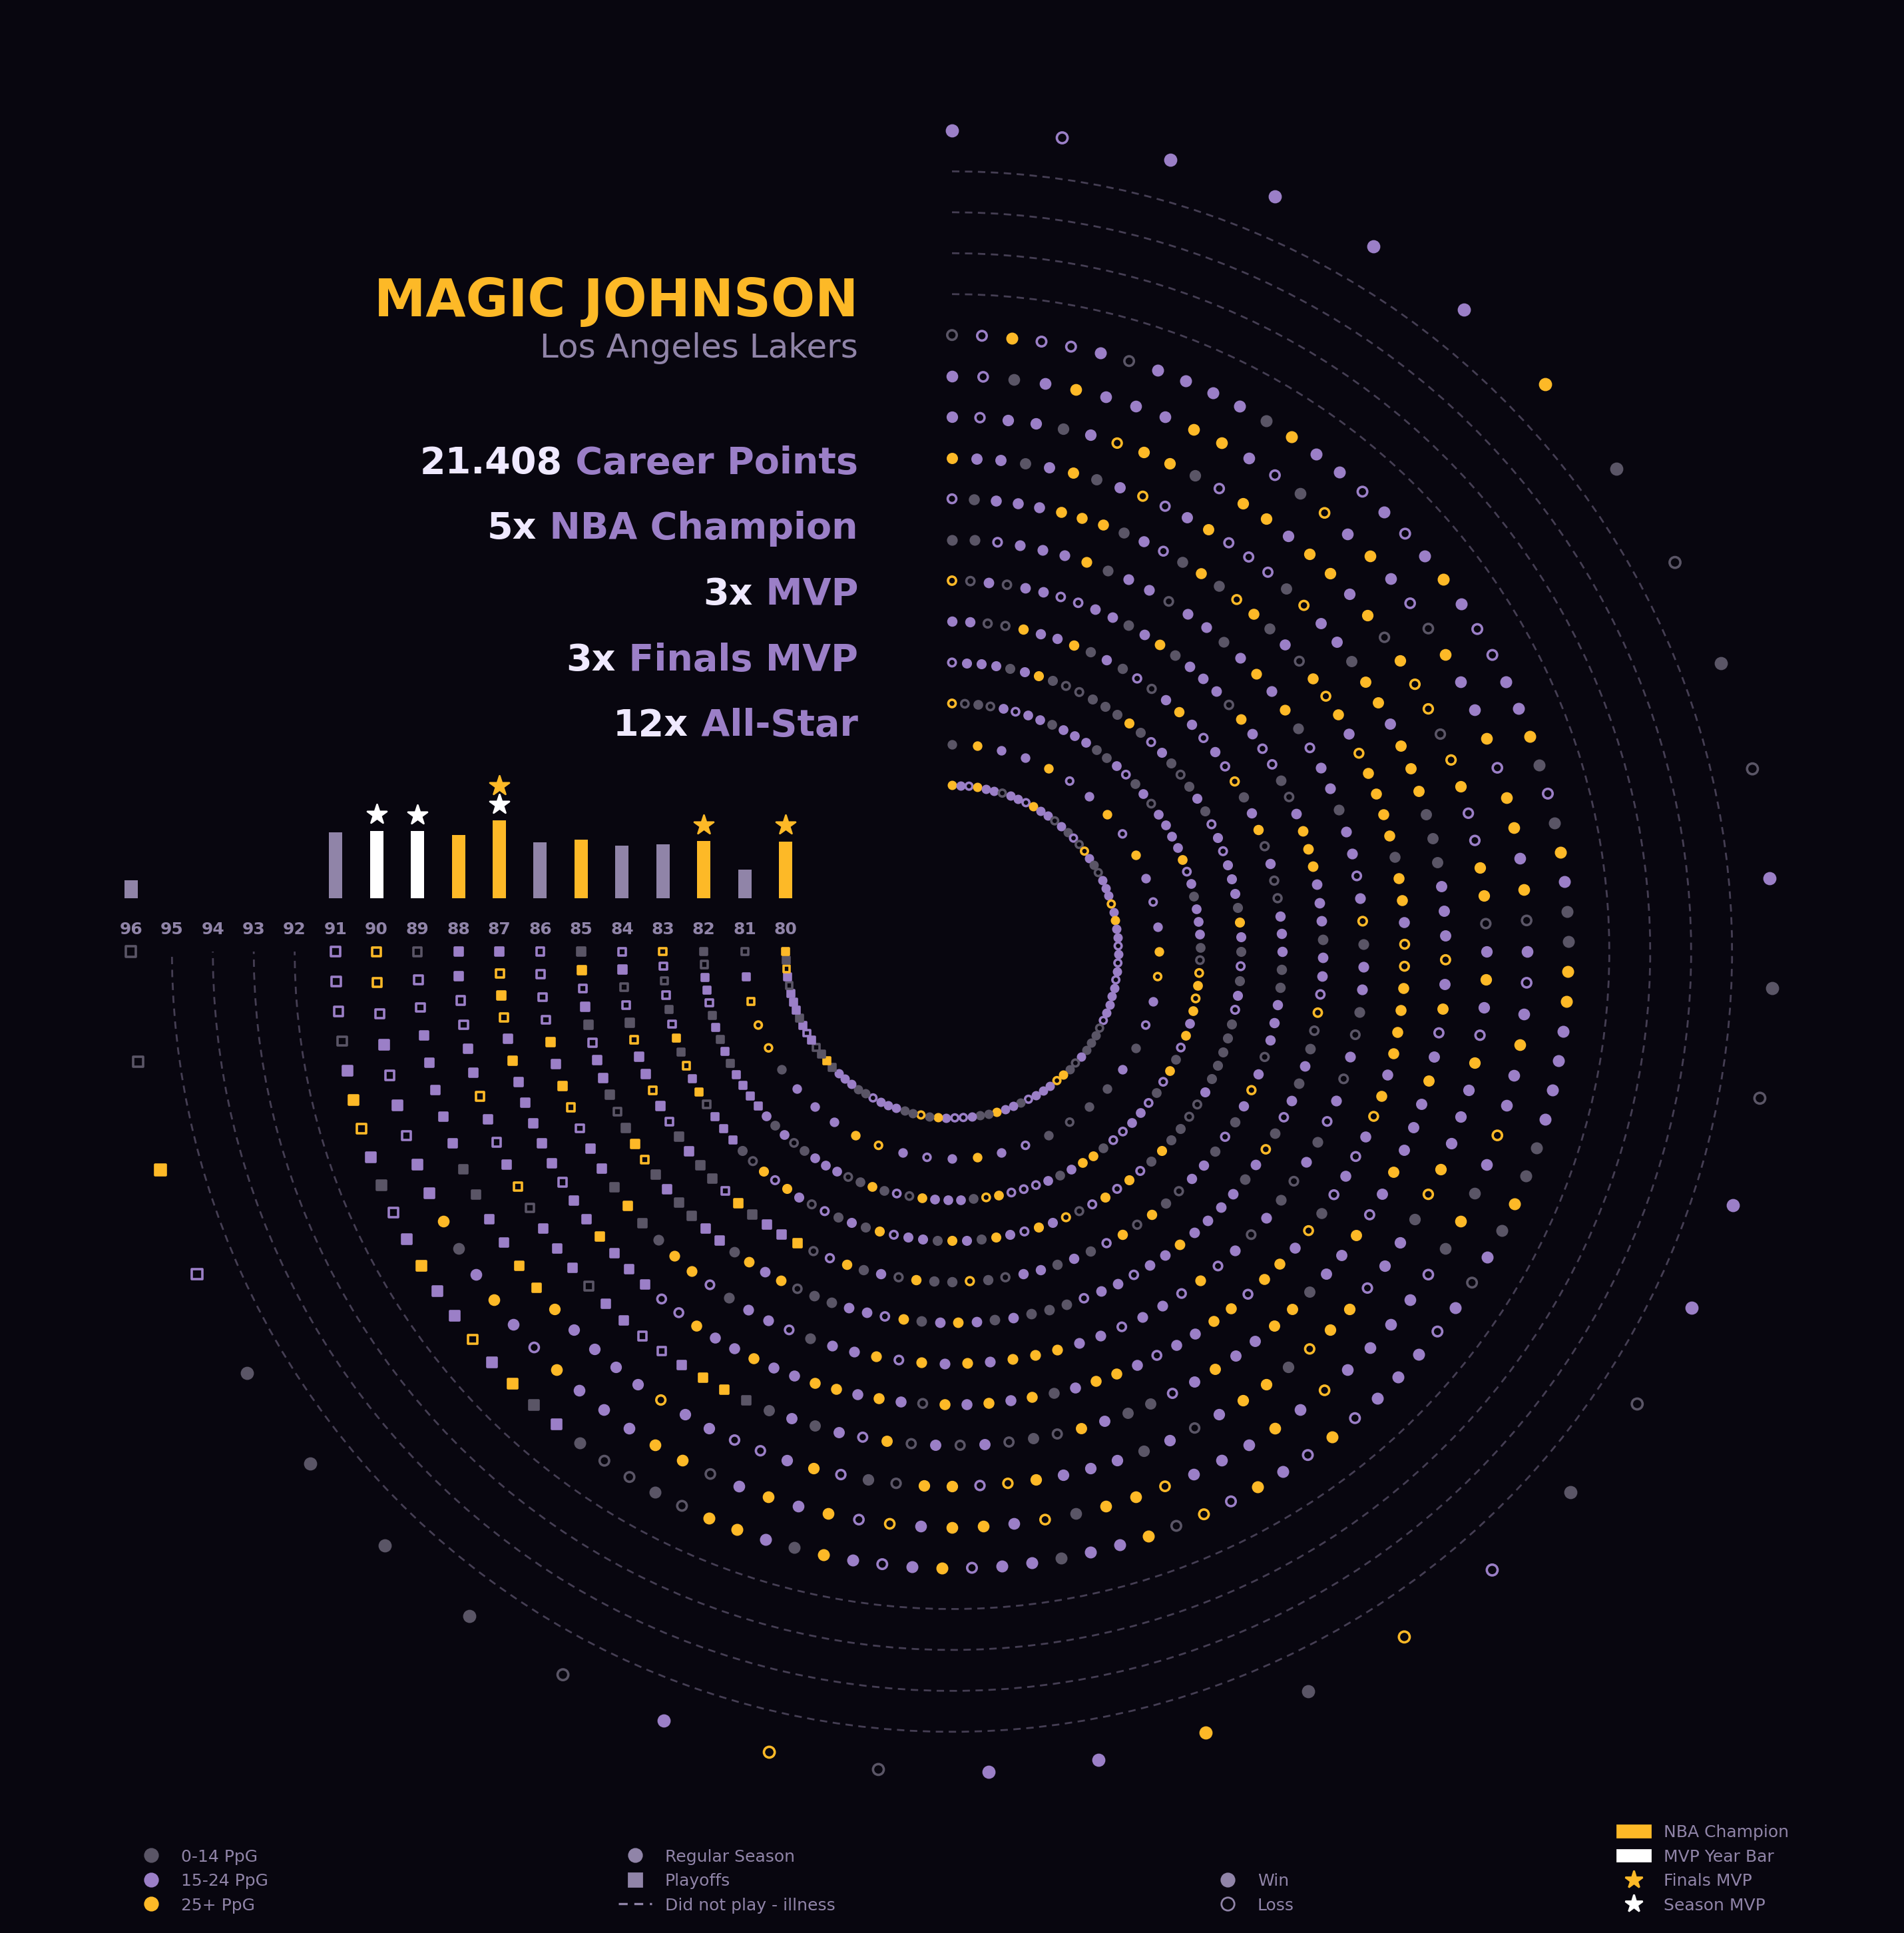

In [5]:
if __name__ == "__main__":
    data = load_all_files(FOLDER)
    plot_career_rings(data)

### 1.6 Display the Saved Image Inline

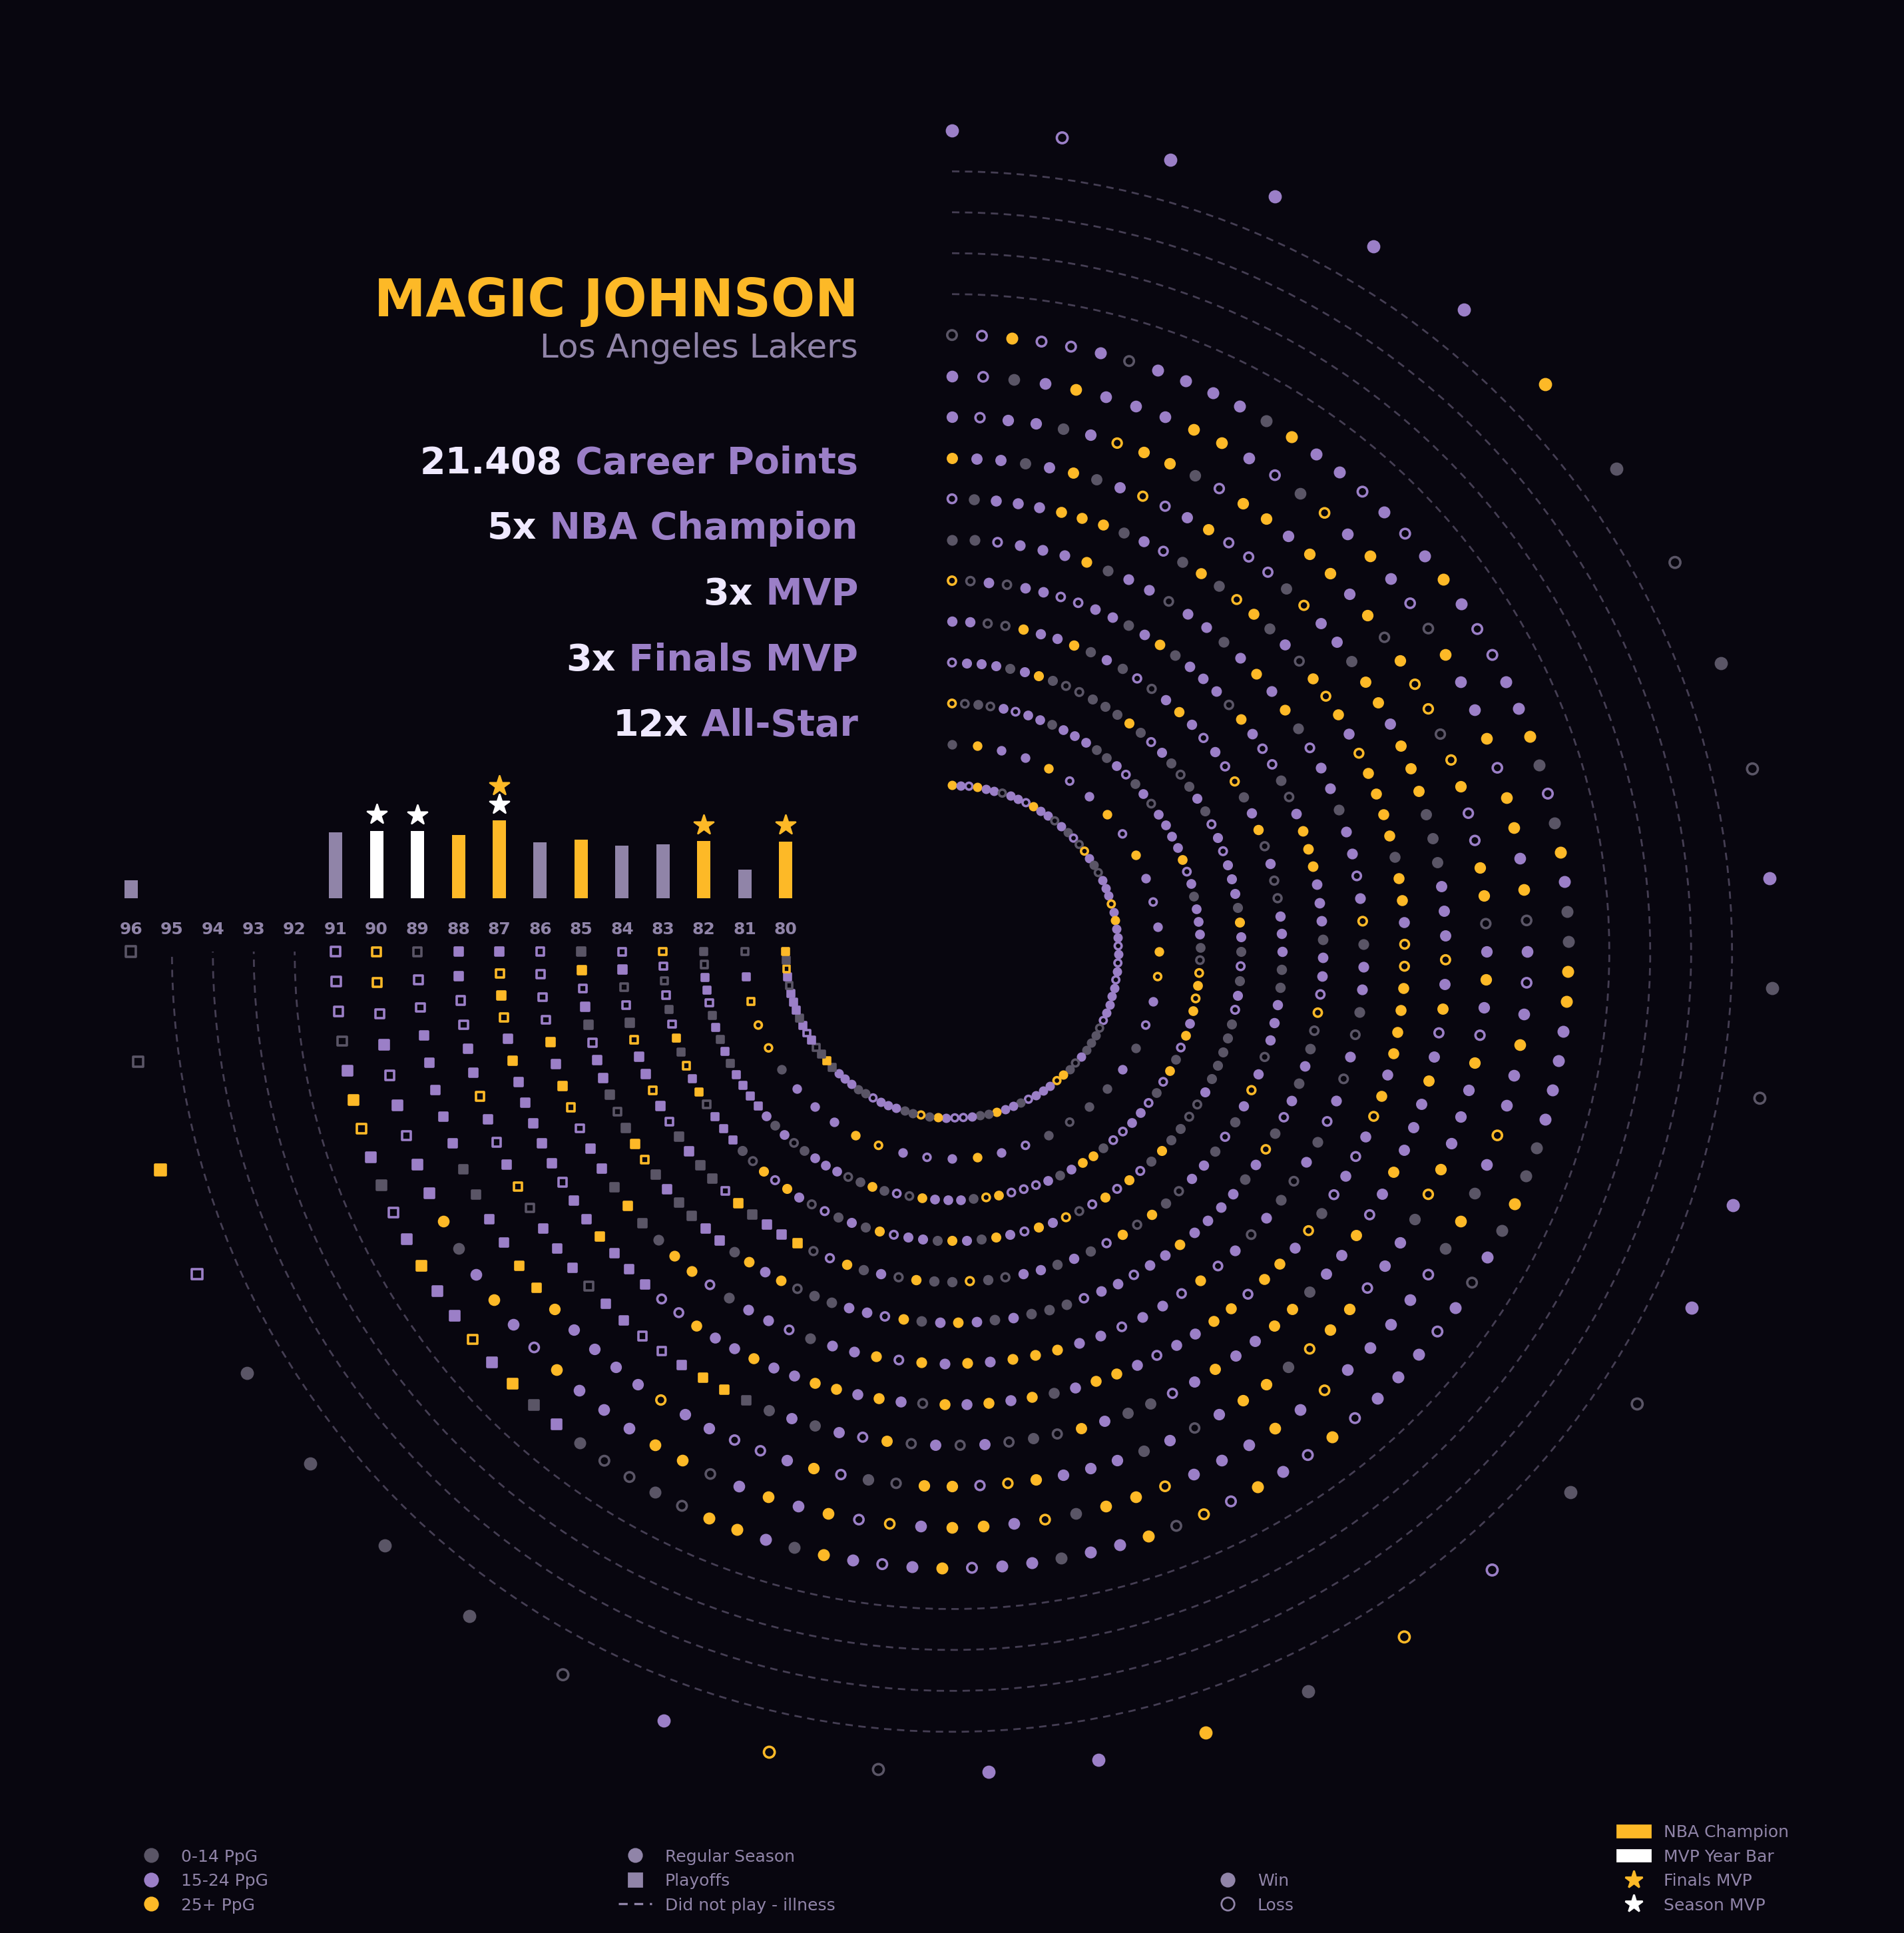

In [8]:
from IPython.display import display
from PIL import Image

# 1. Load the saved PNG
img = Image.open("career_rings.png")

# 2. Embed and display it directly in the notebook
display(img)

## Part 2 — Interactive Chart (HTML/SVG with Tooltips)

Same underlying geometry as the static chart, rendered as an SVG string
instead of matplotlib so every game marker, achievement bar, and star can
carry a hover tooltip. Tooltips use native SVG `<title>` elements — no
JavaScript required, so they work even in notebook environments that strip
`<script>` tags from HTML output.

### 2.1 Imports & Configuration


In [9]:
"""
Interactive HTML/SVG version of the Career Rings chart, with tooltips.
Same geometry/config as the matplotlib script — just rendered as SVG so it
can carry hover tooltips and display inline in a notebook cell.
Tooltips use native SVG <title> elements (no JavaScript needed) — this
works reliably even in notebook environments that strip <script> tags.
"""

import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display

# -----------------------------------------------------------------
# CONFIG — identical to the matplotlib version
# -----------------------------------------------------------------
FOLDER = Path.cwd()
PLAYER_NAME = "MAGIC JOHNSON"
TEAM_LINE = "Los Angeles Lakers"
INCLUDE_PLAYOFFS = True

CHAMPIONSHIP_SEASONS = {"1979-80", "1981-82", "1984-85", "1986-87", "1987-88"}
MVP_SEASONS = {"1986-87", "1988-89", "1989-90"}
FINALS_MVP_SEASONS = {"1979-80", "1981-82", "1986-87"}

ACHIEVEMENT_GOLD = "#FDB927"
ACHIEVEMENT_WHITE = "#FFFFFF"
COLORS = {
    "0-14": "#5A5566",
    "15-24": "#9B7FC7",
    "25+": "#FDB927",
}
BG = "#08060F"
INK = "#EFE9FF"
INK_DIM = "#9084A8"
TEXT_PURPLE = "#9B7FC7"

CAREER_STATS = [
    ("Career Points", "{total_pts}"),
    ("NBA Champion", "5x"),
    ("MVP", "3x"),
    ("Finals MVP", "3x"),
    ("All-Star", "12x"),
]

FILENAME_RE = re.compile(r"(\d{4})(?:-(\d{2}))?\s+(Regular Season|Playoffs)", re.IGNORECASE)

### 2.2 Data Loading (with Home/Away & Score Parsing)

Same filename/table loading as Part 1, plus two additions needed for the
tooltips:
- **Home/away detection**: the "@" marker column has no reliable name
  across export formats, so it's located *positionally* — the column
  immediately before `"Opp"`.
- **Score parsing**: the `Result` column (e.g. `"W 103-102"`) always lists
  the *player's own team* first, regardless of home/away — this is
  reordered into home-team-first for the tooltip, with a regex that
  tolerates hyphens, en-dashes, and irregular spacing, plus a looser
  fallback pattern for anything still unmatched.


In [10]:
def parse_filename(path: Path) -> tuple[str, str]:
    m = FILENAME_RE.search(path.stem)
    if not m:
        raise ValueError(f"Can't parse season/type from filename: {path.name}")
    y1, y2, game_type = m.groups()
    if y2:
        season = f"{y1}-{y2}"
    else:
        start_year = int(y1) - 1
        season = f"{start_year}-{str(int(y1))[2:]}"
    return season, game_type.title()


def read_any_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    try:
        return pd.read_excel(path)
    except Exception:
        tables = pd.read_html(path)
        return tables[0]


def load_all_files(folder: Path) -> pd.DataFrame:
    files = sorted(folder.glob("*.xls")) + sorted(folder.glob("*.xlsx")) + sorted(folder.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No season files found in {folder}")

    frames = []
    for f in files:
        season, game_type = parse_filename(f)
        if not INCLUDE_PLAYOFFS and game_type == "Playoffs":
            continue

        df = read_any_table(f)
        if "Rk" in df.columns:
            df = df[pd.to_numeric(df["Rk"], errors="coerce").notna()]
        if "Date" in df.columns:
            df = df[df["Date"].notna()]

        # The "@" / blank home-away marker sits in the unnamed column right
        # before "Opp" — detect it by position, since its header name varies
        # depending on how the file was exported (blank, "H", "Unnamed: 5"...).
        cols = list(df.columns)
        if "Opp" in cols:
            opp_idx = cols.index("Opp")
            if opp_idx > 0:
                df = df.rename(columns={cols[opp_idx - 1]: "AtSign"})
        if "AtSign" not in df.columns:
            df["AtSign"] = ""
        df["is_away"] = df["AtSign"].astype(str).str.strip() == "@"

        df["PTS"] = pd.to_numeric(df["PTS"], errors="coerce")
        df = df.dropna(subset=["PTS"]).copy()
        df["PTS"] = df["PTS"].astype(int)
        df["Result_WL"] = df["Result"].astype(str).str.strip().str[0]

        # Result string is always "[W/L] [player-team score]-[opponent score]",
        # regardless of home/away — reorder into home-first for the tooltip.
        result_str = df["Result"].astype(str)
        parsed = result_str.str.extract(r"([WL])\s*(\d+)\s*[-\u2013\u2014\u2212]\s*(\d+)")
        still_missing = parsed[1].isna() | parsed[2].isna()
        if still_missing.any():
            # last-resort fallback: just grab the first two numbers in the string,
            # whatever separates them (handles odd export formatting)
            fallback = result_str[still_missing].str.extract(r"([WL]).*?(\d+)\D+(\d+)")
            parsed.loc[still_missing, [0, 1, 2]] = fallback.values
        team_score = pd.to_numeric(parsed[1], errors="coerce")
        opp_score = pd.to_numeric(parsed[2], errors="coerce")
        df["home_team"] = np.where(df["is_away"], df["Opp"], df["Team"])
        df["away_team"] = np.where(df["is_away"], df["Team"], df["Opp"])
        df["home_score"] = np.where(df["is_away"], opp_score, team_score)
        df["away_score"] = np.where(df["is_away"], team_score, opp_score)

        df["season"] = season
        df["game_type"] = game_type
        frames.append(df)

    full = pd.concat(frames, ignore_index=True)
    sort_cols = ["season", "Date"] if "Date" in full.columns else ["season"]
    return full.sort_values(sort_cols).reset_index(drop=True)


def bucket(pts: int) -> str:
    if pts >= 25:
        return "25+"
    elif pts >= 15:
        return "15-24"
    else:
        return "0-14"


def esc(s: str) -> str:
    """Minimal HTML escaping for tooltip text (keeps newlines intact)."""
    return (str(s).replace("&", "&amp;").replace('"', "&quot;")
            .replace("<", "&lt;").replace(">", "&gt;"))


def star_points(cx: float, cy: float, r_outer: float, r_inner: float) -> str:
    pts = []
    for i in range(10):
        ang = math.radians(-90 + i * 36)
        r = r_outer if i % 2 == 0 else r_inner
        pts.append(f"{cx + r*math.cos(ang):.2f},{cy + r*math.sin(ang):.2f}")
    return " ".join(pts)

### 2.3 SVG Chart Builder

Builds the entire chart as one SVG string using the same angle/radius
formulas as Part 1. Notable parameters:

| Parameter | Controls |
|---|---|
| `svg_size` | output canvas size in pixels (SVG scales responsively regardless) |
| `base_circle_r` / `base_square_half` | full-scale marker sizes, in pixels |
| `to_px()` | converts data coordinates (origin center, y-up) to SVG pixel coordinates (origin top-left, y-down) |

Every game marker, achievement bar, and star gets a `<title>` child element
— that's what produces the native hover tooltip, with no JavaScript needed.


In [11]:
def build_interactive_html(df: pd.DataFrame, svg_size: int = 1600) -> str:
    seasons = sorted(df["season"].unique())

    ring_gap, r_inner = 0.32, 1.3
    theta0 = math.radians(90)
    sweep = math.radians(-(360 - 90))

    season_points = df.groupby("season")["PTS"].sum()
    max_season_points = season_points.max()

    start_years = {s: int(s.split("-")[0]) for s in seasons}
    first_year, last_year = min(start_years.values()), max(start_years.values())
    year_span = last_year - first_year
    max_radius = r_inner + year_span * ring_gap

    lim = r_inner + (year_span + 1) * ring_gap + 0.6
    scale = svg_size / (2 * lim)

    def to_px(x, y):
        return (x + lim) * scale, (lim - y) * scale

    total_pts = int(df["PTS"].sum())
    els = []

    els.append(f'<rect x="0" y="0" width="{svg_size}" height="{svg_size}" fill="{BG}"/>')

    # --- title + hard facts (right-aligned block) ---
    text_x_data = -lim * 0.10
    text_px_x, _ = to_px(text_x_data, 0)
    ty = lim * 0.72
    _, title_y = to_px(0, ty)
    els.append(f'<text x="{text_px_x:.1f}" y="{title_y:.1f}" text-anchor="end" '
               f'font-family="sans-serif" font-weight="bold" font-size="46" fill="{ACHIEVEMENT_GOLD}">{esc(PLAYER_NAME)}</text>')
    ty -= lim * 0.06
    _, team_y = to_px(0, ty)
    els.append(f'<text x="{text_px_x:.1f}" y="{team_y:.1f}" text-anchor="end" '
               f'font-family="sans-serif" font-size="27" fill="{INK_DIM}">{esc(TEAM_LINE)}</text>')
    ty -= lim * 0.12

    stats_filled = [(lbl, val.format(total_pts=f"{total_pts:,}".replace(",", "."))
                      if "{total_pts}" in val else val)
                     for lbl, val in CAREER_STATS]
    for stat_label, stat_value in stats_filled:
        _, sy = to_px(0, ty)
        els.append(
            f'<text x="{text_px_x:.1f}" y="{sy:.1f}" text-anchor="end" font-family="sans-serif" font-size="30">'
            f'<tspan font-weight="bold" fill="{INK}">{esc(stat_value)}</tspan>'
            f'<tspan font-weight="bold" fill="{TEXT_PURPLE}"> {esc(stat_label)}</tspan>'
            f'</text>'
        )
        ty -= lim * 0.07

    # --- missing-season dashed rings ---
    missing_years = sorted(y for y in range(first_year, last_year + 1) if y not in start_years.values())
    for y in missing_years:
        r = r_inner + (y - first_year) * ring_gap
        pts = []
        for i in range(151):
            t = i / 150
            ang = theta0 + t * sweep
            pts.append(to_px(r * math.cos(ang), r * math.sin(ang)))
        path_d = "M " + " L ".join(f"{x:.1f},{y_:.1f}" for x, y_ in pts)
        els.append(f'<path d="{path_d}" fill="none" stroke="{INK_DIM}" stroke-width="1.6" '
                   f'stroke-dasharray="7,5" opacity="0.45"/>')

    # --- data rings: one game marker per game, with tooltip ---
    base_circle_r = 6.2   # px, at full scale
    base_square_half = 5.6  # px, at full scale

    for season in seasons:
        radius = r_inner + (start_years[season] - first_year) * ring_gap
        s_games = df[df["season"] == season].reset_index(drop=True)
        n = len(s_games)
        size_scale = 0.55 + 0.45 * (radius / max_radius)

        for i, row in s_games.iterrows():
            t = i / max(n - 1, 1)
            ang = theta0 + t * sweep
            x, y = to_px(radius * math.cos(ang), radius * math.sin(ang))
            color = COLORS[bucket(row["PTS"])]
            is_win = row["Result_WL"] == "W"
            is_playoff = row["game_type"] == "Playoffs"

            date = row.get("Date", "")
            home_team = row.get("home_team", "")
            away_team = row.get("away_team", "")
            home_score = row.get("home_score", None)
            away_score = row.get("away_score", None)
            result_word = "Win" if is_win else "Loss"

            score_txt = (f"{int(home_score)}-{int(away_score)}"
                         if pd.notna(home_score) and pd.notna(away_score) else "?")
            tip = esc(
                f"{date}\n{home_team} vs {away_team}\nFinal: {score_txt}\n"
                f"{result_word}\nMagic Johnson: {int(row['PTS'])} pts"
            )

            fill = color if is_win else "none"
            stroke_w = 1.6

            if is_playoff:
                half = base_square_half * size_scale
                els.append(
                    f'<rect class="mk" x="{x-half:.2f}" y="{y-half:.2f}" '
                    f'width="{half*2:.2f}" height="{half*2:.2f}" fill="{fill}" stroke="{color}" '
                    f'stroke-width="{stroke_w}"><title>{tip}</title></rect>'
                )
            else:
                r = base_circle_r * size_scale
                els.append(
                    f'<circle class="mk" cx="{x:.2f}" cy="{y:.2f}" r="{r:.2f}" '
                    f'fill="{fill}" stroke="{color}" stroke-width="{stroke_w}"><title>{tip}</title></circle>'
                )

    # --- achievement bars, year labels, and stars ---
    end_angle = theta0 + sweep
    bar_half_w = base_square_half

    for y in range(first_year, last_year + 1):
        radius = r_inner + (y - first_year) * ring_gap
        bar_gap = ring_gap * 1.30
        base_x_data, base_y_data = radius * math.cos(end_angle), radius * math.sin(end_angle) + bar_gap
        bx, base_svg_y = to_px(base_x_data, base_y_data)

        matched_season = next((s for s, sy in start_years.items() if sy == y), None)
        short_year = matched_season.split("-")[1] if matched_season else str(y + 1)[-2:]

        _, label_y = to_px(base_x_data, base_y_data - ring_gap * 0.55)
        els.append(f'<text x="{bx:.1f}" y="{label_y:.1f}" text-anchor="middle" '
                   f'font-family="sans-serif" font-weight="bold" font-size="16" fill="{INK_DIM}">{short_year}</text>')

        if not matched_season:
            continue

        if matched_season in CHAMPIONSHIP_SEASONS:
            bar_color = ACHIEVEMENT_GOLD
        elif matched_season in MVP_SEASONS:
            bar_color = ACHIEVEMENT_WHITE
        else:
            bar_color = INK_DIM

        pts_this_season = int(season_points[matched_season])
        bar_height_data = (season_points[matched_season] / max_season_points) * (ring_gap * 1.9)
        top_x_data, top_y_data = base_x_data, base_y_data + bar_height_data
        _, bar_top_svg_y = to_px(top_x_data, top_y_data)
        bar_tip = esc(f"{matched_season}: {pts_this_season:,} pts")

        els.append(
            f'<rect class="mk" x="{bx - bar_half_w:.2f}" y="{bar_top_svg_y:.2f}" '
            f'width="{bar_half_w*2:.2f}" height="{(base_svg_y - bar_top_svg_y):.2f}" '
            f'fill="{bar_color}" stroke="none"><title>{bar_tip}</title></rect>'
        )

        star_y_data = top_y_data + ring_gap * 0.40
        if matched_season in MVP_SEASONS:
            sx, sy = to_px(top_x_data, star_y_data)
            els.append(f'<polygon class="mk" points="{star_points(sx, sy, 11, 4.4)}" '
                       f'fill="{ACHIEVEMENT_WHITE}"><title>{esc(matched_season + " Season MVP")}</title></polygon>')
            star_y_data += ring_gap * 0.45
        if matched_season in FINALS_MVP_SEASONS:
            sx, sy = to_px(top_x_data, star_y_data)
            els.append(f'<polygon class="mk" points="{star_points(sx, sy, 11, 4.4)}" '
                       f'fill="{ACHIEVEMENT_GOLD}"><title>{esc(matched_season + " Finals MVP")}</title></polygon>')

    # --- legend ---
    legend_y = svg_size - 40
    col_x = [svg_size * 0.06, svg_size * 0.34, svg_size * 0.62, svg_size * 0.86]

    def legend_dot(x, y, color, filled=True, shape="circle"):
        if shape == "circle":
            return (f'<circle cx="{x}" cy="{y}" r="6" fill="{color if filled else "none"}" '
                    f'stroke="{color}" stroke-width="1.6"/>')
        if shape == "square":
            return (f'<rect x="{x-5.5}" y="{y-5.5}" width="11" height="11" '
                    f'fill="{color if filled else "none"}" stroke="{color}" stroke-width="1.6"/>')
        if shape == "line":
            return (f'<line x1="{x-9}" y1="{y}" x2="{x+9}" y2="{y}" stroke="{color}" '
                    f'stroke-width="1.6" stroke-dasharray="5,4"/>')
        if shape == "swatch":
            return f'<rect x="{x-9}" y="{y-6}" width="18" height="12" fill="{color}"/>'
        if shape == "star":
            return f'<polygon points="{star_points(x, y, 8, 3.2)}" fill="{color}"/>'

    legend_groups = [
        (col_x[0], [(f"{b} PpG", c, True, "circle") for b, c in COLORS.items()]),
        (col_x[1], [("Regular Season", INK_DIM, True, "circle"),
                    ("Playoffs", INK_DIM, True, "square"),
                    ("Did not play - illness", INK_DIM, True, "line")]),
        (col_x[2], [("Win", INK_DIM, True, "circle"),
                    ("Loss", INK_DIM, False, "circle")]),
        (col_x[3], [("NBA Champion", ACHIEVEMENT_GOLD, True, "swatch"),
                    ("MVP Year Bar", ACHIEVEMENT_WHITE, True, "swatch"),
                    ("Finals MVP", ACHIEVEMENT_GOLD, True, "star"),
                    ("Season MVP", ACHIEVEMENT_WHITE, True, "star")]),
    ]
    for gx, items in legend_groups:
        y0 = legend_y - (len(items) - 1) * 24
        for i, (label, color, filled, shape) in enumerate(items):
            yy = y0 + i * 24
            els.append(legend_dot(gx, yy, color, filled, shape))
            els.append(f'<text x="{gx+18}" y="{yy+5}" font-family="sans-serif" '
                       f'font-size="15" fill="{INK_DIM}">{esc(label)}</text>')

    svg_body = "\n".join(els)

    html = f"""
<div style="background:{BG}; padding:6px; border-radius:8px;">
<svg id="career-rings-svg" viewBox="0 0 {svg_size} {svg_size}" xmlns="http://www.w3.org/2000/svg" style="width:100%; height:auto; display:block;">
{svg_body}
</svg>
</div>
<style>
  .mk {{ cursor: pointer; transition: opacity .1s ease; }}
  .mk:hover {{ opacity: 0.7; }}
</style>
"""
    return html

### 2.4 Run — Generate & Display Interactively

In [12]:
data = load_all_files(FOLDER)
html = build_interactive_html(data)
display(HTML(html))

### 2.5 Export to a Standalone HTML File

Saves the interactive chart to a file so it can be opened directly in a
browser or shared outside the notebook.


In [13]:
with open("magic_johnson_career.html", "w", encoding="utf-8") as f:
    f.write(html)
print("Saved: magic_johnson_career.html")

Saved: magic_johnson_career.html
